# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


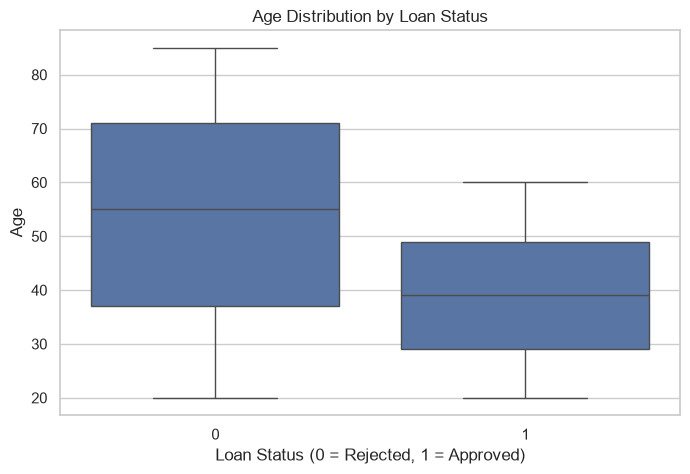

In [2]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='loan_status', y='person_age')
plt.title('Age Distribution by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Age')
plt.show()

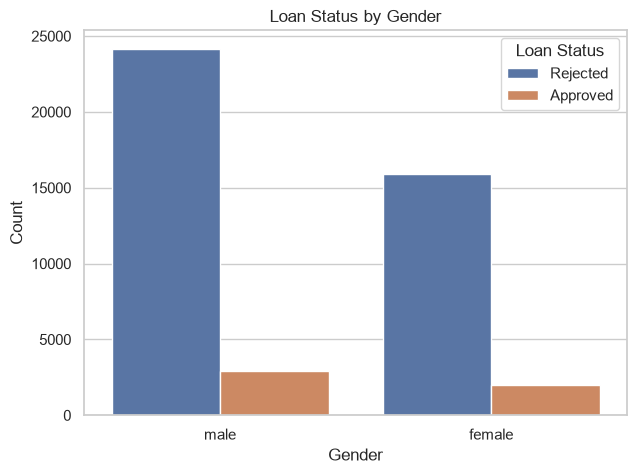

In [3]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='person_gender', hue='loan_status')
plt.title('Loan Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Loan Status', labels=['Rejected', 'Approved'])
plt.show()

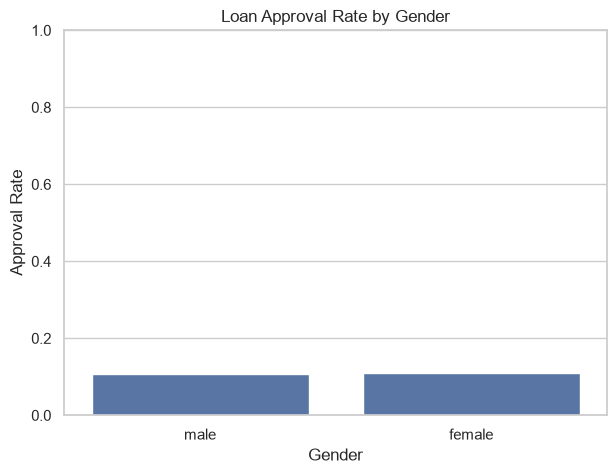

In [4]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='person_gender', y='loan_status', errorbar=None)
plt.title('Loan Approval Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Approval Rate')
plt.ylim(0, 1)
plt.show()

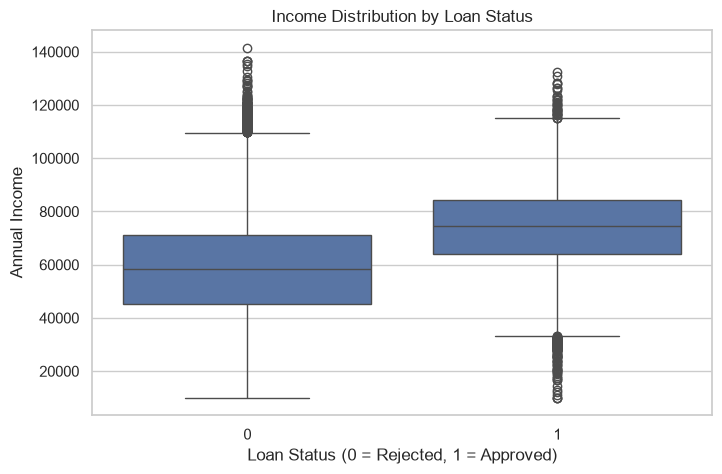

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='loan_status', y='person_income')
plt.title('Income Distribution by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Annual Income')
plt.show()

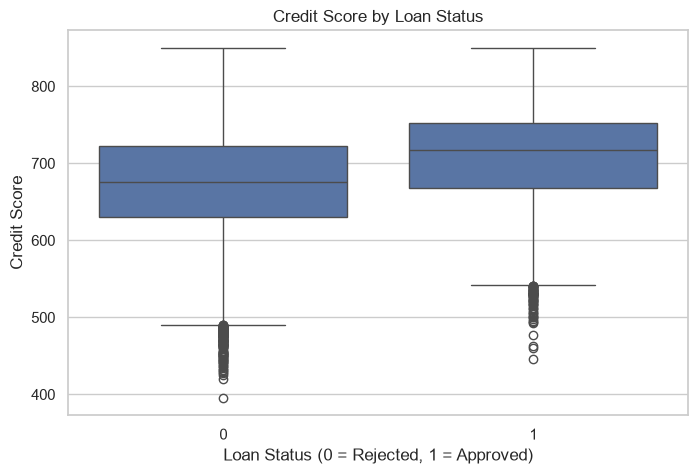

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='loan_status', y='credit_score')
plt.title('Credit Score by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Credit Score')
plt.show()

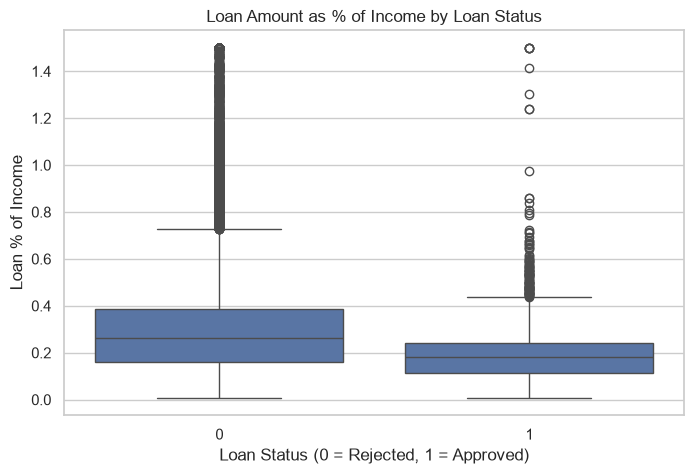

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='loan_status', y='loan_percent_income')
plt.title('Loan Amount as % of Income by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Loan % of Income')
plt.show()

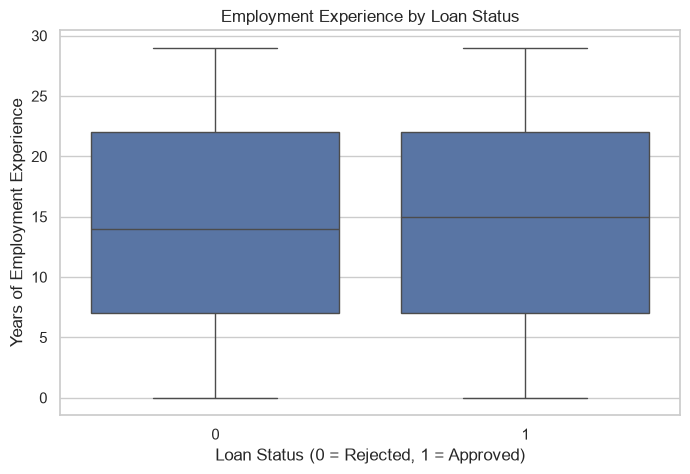

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='loan_status', y='person_emp_exp')
plt.title('Employment Experience by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Years of Employment Experience')
plt.show()

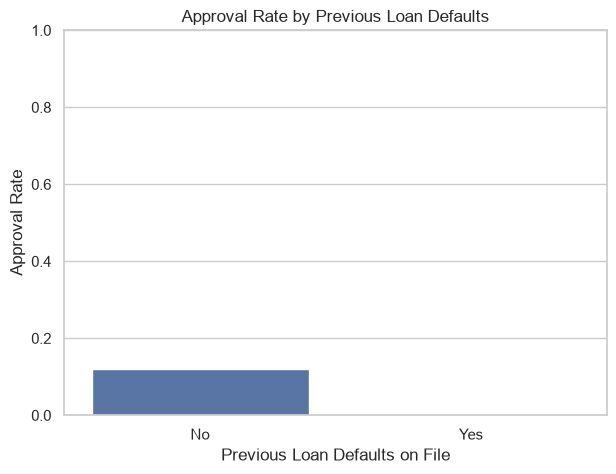

In [9]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='previous_loan_defaults_on_file', y='loan_status', errorbar=None)
plt.title('Approval Rate by Previous Loan Defaults')
plt.xlabel('Previous Loan Defaults on File')
plt.ylabel('Approval Rate')
plt.ylim(0, 1)
plt.show()

In [ ]:
Which features seem to drive the model’s decision to grant a loan?

Loan percent of income — Approved applicants request a much smaller percentage of their income (boxplot shows clearly lower values for status = 1).
Previous loan defaults — Applicants with previous defaults have almost 0% approval rate.
Person income — Approved applicants have higher median incomes.
Credit score — Approved applicants tend to have higher credit scores.
Age — Approved applicants are generally younger than rejected ones.

Which features seem unrelated?

Gender — Approval rates are nearly identical for males and females (~10–11%).
Employment experience — The distribution of years of experience looks almost the same for approved and rejected applicants.

Should the financial institution be concerned about potential legal trouble?

Gender does not appear to be a problem, the approval rates are essentially the same. However, there is a noticeable age difference (younger applicants are more likely to be approved). The bank should make sure that age is not being used in a way that could be considered discriminatory, especially if it is not strongly justified by risk.